### Load Libary

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

### Load Dataset

In [2]:
#Nama dataframe adalah df yang berisi data dari Salary_Data.csv
#Hanya menggunakan kolom YearsExperience dan Salary
df = pd.read_csv('Salary_data.csv', usecols=['YearsExperience', 'Salary'])

### Sneak Peak data

In [3]:
#Melihat 5 baris teratas dari data
#Independent variabel(x) adalah YearsExperience
#Dependent variabel(y) adalah Salary
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [4]:
#Mengetahui jumlah kolom dan baris dari data
#Data kita mempunya 2 kolom dengan 200 baris
df.shape

(30, 2)

In [5]:
#Melihat informasi data kita mulai dari jumlah data, tipe data, memory yang digunakan dll.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes


In [6]:
#Melihat statistical description dari data mulai dari mean, kuartil, standard deviation dll
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


### Handling Missing Values

In [7]:
#Mencari dan menangani missing values
#data tidak ada missing values
df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

### Exploratory Data Analysis (EDA)

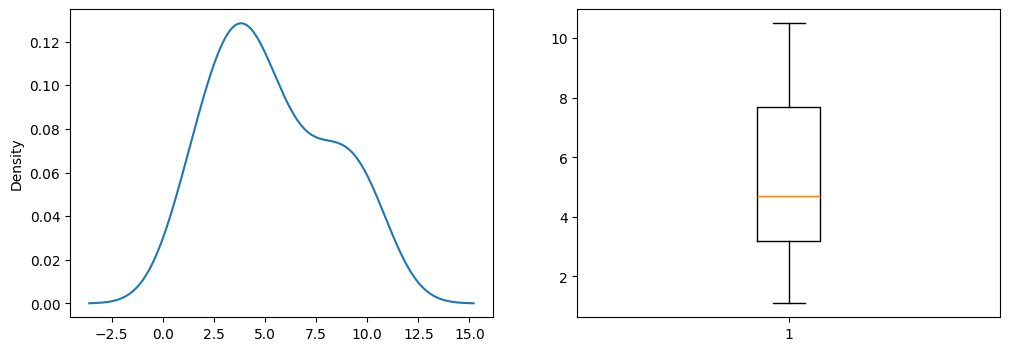

In [8]:
#Univariate analysis YearsExperinece
#Melihat distribusi dari YearsExperinece
f = plt.figure(figsize=(12,4))

f.add_subplot(1,2,1)
df['YearsExperience'].plot(kind='kde')

f.add_subplot(1,2,2)
plt.boxplot(df['YearsExperience'])
plt.show()

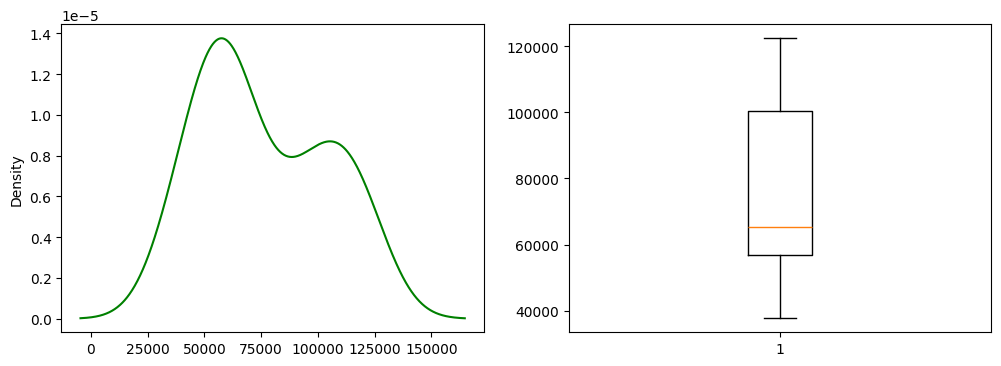

In [9]:
#Univariate analysis Salary
#Melihat distribusi dari Salary
f = plt.figure(figsize=(12,4))

f.add_subplot(1,2,1)
df['Salary'].plot(kind='kde', c='g')

f.add_subplot(1,2,2)
plt.boxplot(df['Salary'])
plt.show()

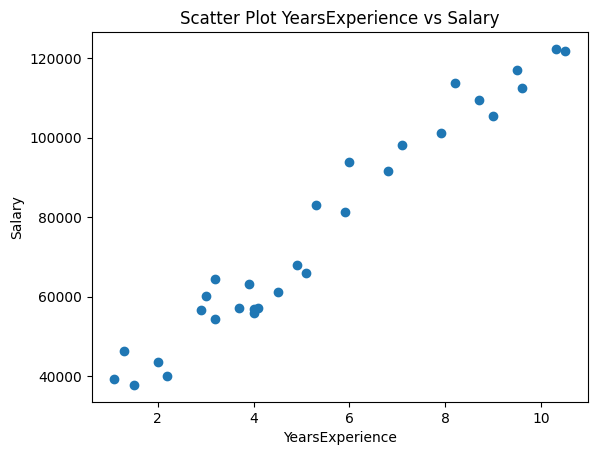

In [10]:
#Bivariate analysis YearsExperience dan Salary
#Menggunakan scatter plot
plt.scatter(df['YearsExperience'], df['Salary'])
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('Scatter Plot YearsExperience vs Salary')
plt.show()

In [11]:
df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


### Modeling

In [12]:
#Recall data 
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [13]:
#buat variabel x dan y
x = df['YearsExperience'].values.reshape(-1,1)
y = df['Salary'].values.reshape(-1,1)

In [14]:
#Kedua, split data kita menjadi training and testing dengan porsi 80:20
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [15]:
#Ketiga, bikin object linear regresi
lin_reg = LinearRegression()

In [16]:
#Keempat, train the model menggunakan training data yang sudah displit
lin_reg.fit(x_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
#Kelima, cari tau nilai slope/koefisien (m) dan intercept (b)
print(lin_reg.coef_)
print(lin_reg.intercept_)

[[9273.90976249]]
[26330.07179879]


In [18]:
#Keenam, cari tahu accuracy score dari model kita menggunakan testing data yang sudah displit
lin_reg.score(x_test, y_test)

0.9461797982902798

Text(0.5, 1.0, 'Plot YearsExperience vs Salary')

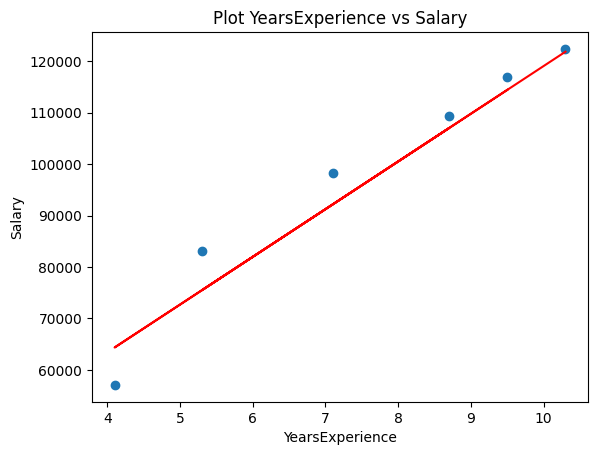

In [19]:
#Ketujuh, visualisasi aktual vs prediksi menggunakan data testing
#Garis merah merupakan garis regresi dari persamaan yang kita dapat tadi
y_prediksi = lin_reg.predict(x_test)
plt.scatter(x_test, y_test)
plt.plot(x_test, y_prediksi, c='r')
plt.xlabel('YearsExperience')
plt.ylabel('Salary')
plt.title('Plot YearsExperience vs Salary')

### Prediction

In [20]:
lin_reg.predict([[100]])

array([[953721.0480479]])

In [21]:
lin_reg.predict([[150]])

array([[1417416.53617245]])

In [22]:
lin_reg.predict([[200]])

array([[1881112.02429701]])